# Notebook 1 — Constant-velocity 2-D tracking with the linear Kalman filter

**Goal**: learn the process-noise covariance **Q** and measurement-noise covariance **R** of a
constant-velocity tracker from data, using the production `automatic_kalman` API.

State: `[x, y, vx, vy]` (2-D position + velocity).  
Measurement: `[x, y]` (position only, no velocity observed).  
Noise model: diagonal Q (independent axis noise), diagonal R.

We compare two training paths:
- **NIS** — Normalized Innovation Squared, requires no ground-truth state.
- **NEES** — Normalized Estimation Error Squared, uses ground-truth state.

**Done when**: NIS on the held-out set lies within the chi-squared confidence band.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Ellipse
from torch.utils.data import DataLoader

from automatic_kalman.covariance import CholeskyCovariance
from automatic_kalman.data.generators import LinearGaussianGenerator, TrajectoryDataset
from automatic_kalman.filters.kf import KalmanFilter
from automatic_kalman.losses import nees_consistency, nis_consistency
from automatic_kalman.train import train

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 4)})

## 1  System definition

Discrete-time constant-velocity model with `dt = 0.1 s`:

$$x_{k+1} = F x_k + w_k, \quad z_k = H x_k + v_k$$

$$F = \begin{pmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{pmatrix}, \quad
H = \begin{pmatrix}1&0&0&0\\0&1&0&0\end{pmatrix}$$

**True covariances** (what we are trying to learn):  
`Q_true = diag(1e-4, 1e-4, 1e-2, 1e-2)` — position and velocity process noise.  
`R_true = 0.5 · I₂` — position measurement noise.

In [2]:
dt = 0.1
dim_x, dim_z = 4, 2

F = torch.tensor(
    [[1.0, 0.0, dt,  0.0],
     [0.0, 1.0, 0.0, dt ],
     [0.0, 0.0, 1.0, 0.0],
     [0.0, 0.0, 0.0, 1.0]],
    dtype=torch.float64,
)
H = torch.tensor(
    [[1.0, 0.0, 0.0, 0.0],
     [0.0, 1.0, 0.0, 0.0]],
    dtype=torch.float64,
)

Q_true = torch.diag(torch.tensor([1e-4, 1e-4, 1e-2, 1e-2], dtype=torch.float64))
R_true = 0.5 * torch.eye(dim_z, dtype=torch.float64)

# Target starts at the origin moving diagonally at (1, 0.5) m/s
x0 = torch.tensor([0.0, 0.0, 1.0, 0.5], dtype=torch.float64)

kf = KalmanFilter(F, H)
print(f"Q_true diagonal: {Q_true.diagonal().tolist()}")
print(f"R_true diagonal: {R_true.diagonal().tolist()}")

Q_true diagonal: [0.0001, 0.0001, 0.01, 0.01]
R_true diagonal: [0.5, 0.5]


## 2  Data generation

We generate 200 independent trajectories of 50 steps for training and 500 for evaluation.
The `LinearGaussianGenerator` simulates the true system exactly.

In [3]:
torch.manual_seed(0)
gen = LinearGaussianGenerator(F, H, Q_true, R_true, x0=x0)

batch_train = gen(B=200, T=50)
batch_eval  = gen(B=500, T=50)

dataset = TrajectoryDataset(batch_train)
loader  = DataLoader(dataset, batch_size=20, shuffle=True)

print(f"Train: {batch_train.measurements.shape}  (B, T, dim_z)")
print(f"Eval:  {batch_eval.measurements.shape}")

Train: torch.Size([200, 50, 2])  (B, T, dim_z)
Eval:  torch.Size([500, 50, 2])


## 3  Covariance initialisation helpers

We deliberately mis-initialise Q and R at **10× the true scale** to demonstrate recovery.

In [4]:
def softplus_inv(x: torch.Tensor) -> torch.Tensor:
    """Inverse of softplus: log(exp(x) - 1)."""
    return torch.log(torch.expm1(x))


def init_cov_at_scale(
    cov: CholeskyCovariance,
    L_true: torch.Tensor,
    scale: float,
) -> None:
    """Set cov._L_raw so that factor() ≈ scale * L_true."""
    with torch.no_grad():
        target = scale * L_true
        L_raw = target.clone()
        L_raw.diagonal().copy_(softplus_inv(target.diagonal()))
        cov._L_raw.data.copy_(L_raw)


L_Q_true = torch.linalg.cholesky(Q_true)
L_R_true = torch.linalg.cholesky(R_true)
INIT_SCALE = math.sqrt(10.0)  # factor() = sqrt(10)*L_true → matrix() ≈ 10*Q/R_true

## 4  Training — NIS path

We minimise `(mean_NIS − dim_z)² + λ · mean(log det S)`.  
No ground-truth state is required; only the measurement sequence is used.

In [5]:
torch.manual_seed(1)
cov_Q_nis = CholeskyCovariance(dim=dim_x)
cov_R_nis = CholeskyCovariance(dim=dim_z)
init_cov_at_scale(cov_Q_nis, L_Q_true, INIT_SCALE)
init_cov_at_scale(cov_R_nis, L_R_true, INIT_SCALE)

x0_f = torch.zeros(dim_x, dtype=torch.float64)
P0_f = torch.eye(dim_x, dtype=torch.float64)

losses_nis = train(
    filter=kf,
    cov_Q=cov_Q_nis,
    cov_R=cov_R_nis,
    loss_fn=nis_consistency,
    loader=loader,
    x0=x0_f,
    P0=P0_f,
    epochs=200,
    lr=0.02,
)

print(f"NIS  loss: {losses_nis[0]:.4f} → {losses_nis[-1]:.4f}")

NIS  loss: 6.5585 → -1.1471


## 5  Training — NEES path

We minimise `(mean_NEES − dim_x)² + λ · mean(log det P)`.  
Ground-truth states from the generator are used automatically by the `train` loop
(the `DataLoader` yields `(measurements, states)` pairs).

In [6]:
torch.manual_seed(2)
cov_Q_nees = CholeskyCovariance(dim=dim_x)
cov_R_nees = CholeskyCovariance(dim=dim_z)
init_cov_at_scale(cov_Q_nees, L_Q_true, INIT_SCALE)
init_cov_at_scale(cov_R_nees, L_R_true, INIT_SCALE)

losses_nees = train(
    filter=kf,
    cov_Q=cov_Q_nees,
    cov_R=cov_R_nees,
    loss_fn=nees_consistency,
    loader=loader,
    x0=x0_f,
    P0=P0_f,
    epochs=200,
    lr=0.02,
)

print(f"NEES loss: {losses_nees[0]:.4f} → {losses_nees[-1]:.4f}")

NEES loss: 9.9452 → -9.5516


## 6  Loss curves

Both losses should decrease monotonically toward zero — indicating the filter is approaching consistency.

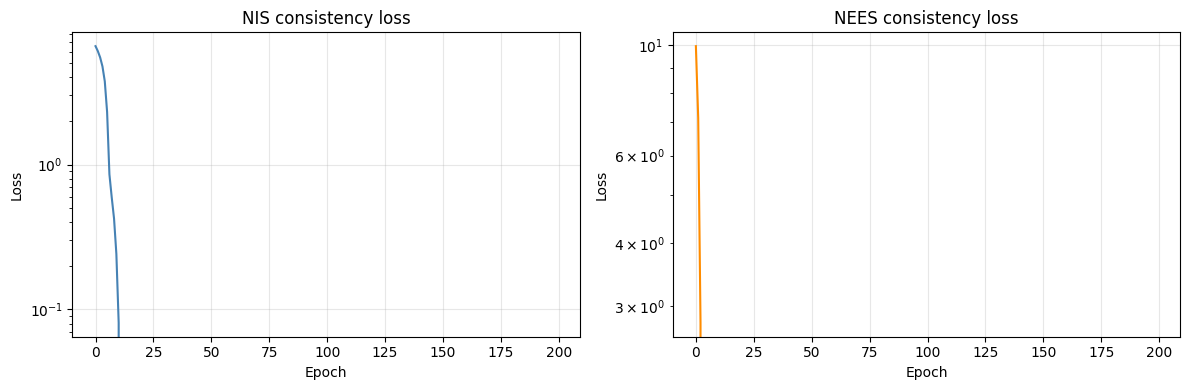

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, losses, label, color in [
    (axes[0], losses_nis,  "NIS",  "steelblue"),
    (axes[1], losses_nees, "NEES", "darkorange"),
]:
    ax.plot(losses, color=color)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{label} consistency loss")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7  Learned Q and R vs ground truth

We compare the diagonal of the learned covariance matrices against the true values.  
The NIS and NEES paths may converge to different (Q, R) pairs that both achieve consistency —
exact Q/R recovery is not guaranteed (the problem is under-identified), but NIS consistency is.

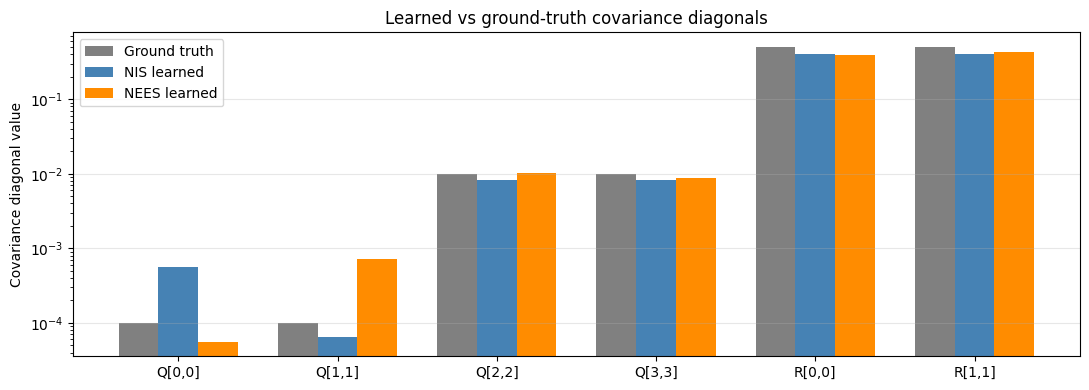

In [8]:
with torch.no_grad():
    Q_nis  = cov_Q_nis.matrix().detach()
    R_nis  = cov_R_nis.matrix().detach()
    Q_nees = cov_Q_nees.matrix().detach()
    R_nees = cov_R_nees.matrix().detach()

labels = ["Q[0,0]", "Q[1,1]", "Q[2,2]", "Q[3,3]", "R[0,0]", "R[1,1]"]
truth  = torch.cat([Q_true.diagonal(), R_true.diagonal()]).numpy()
nis_v  = torch.cat([Q_nis.diagonal(),  R_nis.diagonal()]).numpy()
nees_v = torch.cat([Q_nees.diagonal(), R_nees.diagonal()]).numpy()

x_pos = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_pos - width, truth,  width, label="Ground truth",  color="gray")
ax.bar(x_pos,         nis_v,  width, label="NIS learned",   color="steelblue")
ax.bar(x_pos + width, nees_v, width, label="NEES learned",  color="darkorange")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_ylabel("Covariance diagonal value")
ax.set_title("Learned vs ground-truth covariance diagonals")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8  NIS on held-out data

Under correct tuning, `NIS_k ~ χ²(dim_z)` so `E[NIS] = dim_z = 2`.
We plot the mean per-step NIS across the evaluation batch together with a
5-sigma confidence band derived from the CLT.

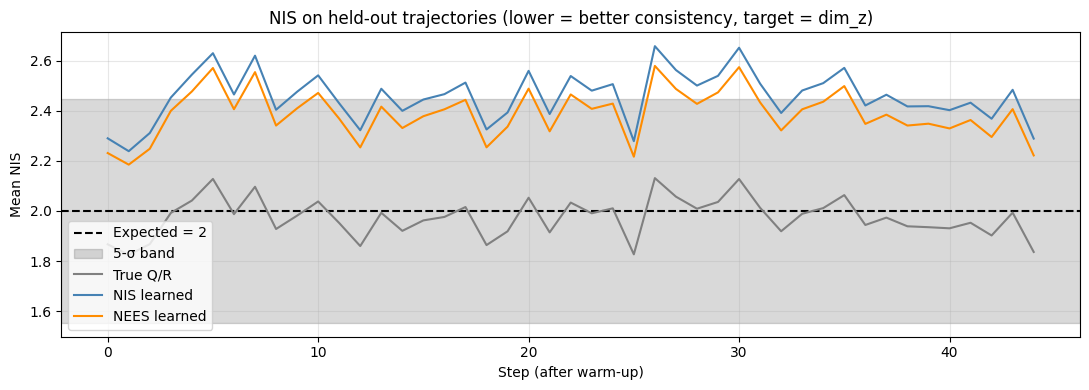

In [9]:
def run_nis_per_step(
    measurements: torch.Tensor,
    Q: torch.Tensor,
    R: torch.Tensor,
    skip: int = 5,
) -> list[float]:
    """Return mean NIS at each time step (after skip warm-up steps)."""
    B, T, _ = measurements.shape
    x = torch.zeros(B, dim_x, dtype=torch.float64)
    P = torch.eye(dim_x, dtype=torch.float64).unsqueeze(0).expand(B, -1, -1).clone()
    nis_steps = []
    with torch.no_grad():
        for t in range(T):
            x, P = kf.predict(x, P, Q)
            x, P, y, S = kf.update(x, P, measurements[:, t, :], R)
            if t >= skip:
                L_S = torch.linalg.cholesky(S)
                nis = (y * torch.cholesky_solve(y.unsqueeze(-1), L_S).squeeze(-1)).sum(-1)
                nis_steps.append(nis.mean().item())
    return nis_steps


z_eval = batch_eval.measurements
nis_nis  = run_nis_per_step(z_eval, Q_nis,  R_nis)
nis_nees = run_nis_per_step(z_eval, Q_nees, R_nees)
nis_true = run_nis_per_step(z_eval, Q_true, R_true)

# 5-sigma CLT band for mean NIS with B=500 samples per step
se5 = 5.0 * math.sqrt(2.0 * dim_z / len(z_eval))

fig, ax = plt.subplots(figsize=(11, 4))
steps = list(range(len(nis_true)))
ax.axhline(dim_z, color="black", linestyle="--", label=f"Expected = {dim_z}")
ax.axhspan(dim_z - se5, dim_z + se5, alpha=0.15, color="black", label="5-σ band")
ax.plot(steps, nis_true,  color="gray",        label="True Q/R")
ax.plot(steps, nis_nis,   color="steelblue",   label="NIS learned")
ax.plot(steps, nis_nees,  color="darkorange",  label="NEES learned")
ax.set_xlabel("Step (after warm-up)")
ax.set_ylabel("Mean NIS")
ax.set_title("NIS on held-out trajectories (lower = better consistency, target = dim_z)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9  Track visualization with 3-σ uncertainty ellipses

We visualise one held-out trajectory:
- **Black line**: true position.
- **Grey dots**: noisy measurements.
- **Blue line**: filter estimate (NIS-learned Q/R).
- **Blue ellipses**: 3-σ uncertainty region in the x-y plane (position subcovariance) at selected steps.

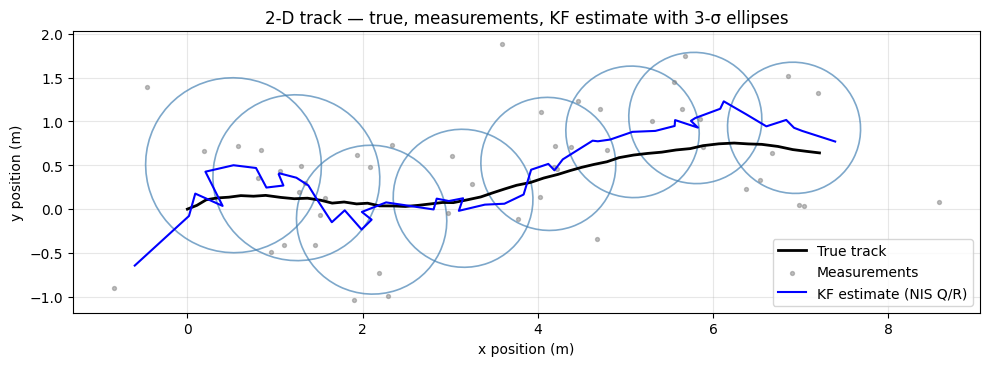

In [10]:
def add_cov_ellipse(
    ax: plt.Axes,
    mean: np.ndarray,
    cov2x2: np.ndarray,
    n_std: float = 3.0,
    **kwargs,
) -> None:
    """Draw a covariance ellipse onto ax."""
    vals, vecs = np.linalg.eigh(cov2x2)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(
        xy=mean,
        width=2 * n_std * math.sqrt(max(vals[0], 0.0)),
        height=2 * n_std * math.sqrt(max(vals[1], 0.0)),
        angle=angle,
        fill=False,
        **kwargs,
    )
    ax.add_patch(ell)


traj_idx = 0
z_one   = batch_eval.measurements[traj_idx]    # (T, dim_z)
x_true  = batch_eval.states[traj_idx]          # (T, dim_x)
T_eval  = z_one.shape[0]

# Run filter on this single trajectory
x_filt = torch.zeros(1, dim_x, dtype=torch.float64)
P_filt = torch.eye(dim_x, dtype=torch.float64).unsqueeze(0).clone()
xs, Ps = [], []
with torch.no_grad():
    for t in range(T_eval):
        x_filt, P_filt = kf.predict(x_filt, P_filt, Q_nis)
        x_filt, P_filt, _, _ = kf.update(x_filt, P_filt, z_one[t:t+1], R_nis)
        xs.append(x_filt[0].numpy().copy())
        Ps.append(P_filt[0].numpy().copy())

xs = np.array(xs)     # (T, 4)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_true[:, 0].numpy(), x_true[:, 1].numpy(), "k-",  lw=2,  label="True track",  zorder=4)
ax.scatter(z_one[:, 0].numpy(), z_one[:, 1].numpy(), c="gray", s=8, alpha=0.5, label="Measurements", zorder=3)
ax.plot(xs[:, 0], xs[:, 1], "b-", lw=1.5, label="KF estimate (NIS Q/R)", zorder=5)

# 3-σ ellipses every ~6 steps (skip first 5 warm-up)
ellipse_steps = range(5, T_eval, 6)
for t in ellipse_steps:
    add_cov_ellipse(
        ax,
        mean=xs[t, :2],
        cov2x2=Ps[t][:2, :2],
        n_std=3.0,
        edgecolor="steelblue",
        linewidth=1.2,
        alpha=0.7,
        zorder=2,
    )

ax.set_aspect("equal")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_title("2-D track — true, measurements, KF estimate with 3-σ ellipses")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10  Comparison table

Summary of ground truth, NIS-learned, NEES-learned, and manual baseline covariances.
**Manual baseline**: Q = 10 × Q_true, R = 10 × R_true (i.e., the mis-initialised starting point,
kept without training).

In [11]:
Q_manual = 10.0 * Q_true
R_manual = 10.0 * R_true
nis_manual = run_nis_per_step(z_eval, Q_manual, R_manual)

# Mean NIS over the evaluation run (lower = closer to dim_z = 2 is better)
def mean_nis(nis_list: list) -> float:
    return float(np.mean(nis_list))

row_fmt = "{:<22}  {:>12}  {:>12}  {:>12}  {:>12}  {:>12}"
header = row_fmt.format(
    "Configuration", "Q diag[0]", "Q diag[2]", "R diag[0]", "R diag[1]", "mean NIS"
)
sep = "-" * len(header)
print(header)
print(sep)

configs = [
    ("Ground truth",    Q_true,    R_true,    mean_nis(nis_true)),
    ("NIS learned",     Q_nis,     R_nis,     mean_nis(nis_nis)),
    ("NEES learned",    Q_nees,    R_nees,    mean_nis(nis_nees)),
    ("Manual baseline", Q_manual,  R_manual,  mean_nis(nis_manual)),
]

for name, Q_c, R_c, mnis in configs:
    with torch.no_grad():
        qd = Q_c.diagonal()
        rd = R_c.diagonal()
    print(row_fmt.format(
        name,
        f"{qd[0].item():.2e}",
        f"{qd[2].item():.2e}",
        f"{rd[0].item():.2e}",
        f"{rd[1].item():.2e}",
        f"{mnis:.3f}",
    ))

print(sep)
print(f"\nTarget mean NIS = {dim_z} (chi-squared expected value with dim_z = {dim_z} degrees of freedom)")

Configuration              Q diag[0]     Q diag[2]     R diag[0]     R diag[1]      mean NIS
--------------------------------------------------------------------------------------------
Ground truth                1.00e-04      1.00e-02      5.00e-01      5.00e-01         1.973
NIS learned                 5.59e-04      8.25e-03      4.02e-01      3.98e-01         2.458
NEES learned                5.62e-05      1.04e-02      3.97e-01      4.25e-01         2.389
Manual baseline             1.00e-03      1.00e-01      5.00e+00      5.00e+00         0.209
--------------------------------------------------------------------------------------------

Target mean NIS = 2 (chi-squared expected value with dim_z = 2 degrees of freedom)
